In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [ ]:
csv_customer = "data_raw/Customers.csv"
csv_superstore = "data_raw/Global_Superstore2.csv"

df_customers = pd.read_csv(csv_customer, index_col= False, header = 0)
df_superstore = pd.read_csv(csv_superstore, index_col= False, encoding="latin1")


In [3]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [4]:
df_customers.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object

In [5]:
df_superstore.shape

(51290, 24)

In [6]:
df_superstore['CustomerID'] = pd.factorize(df_superstore['Customer Name'])[0] + 1
df_superstore.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
CustomerID          int64
dtype: object

In [7]:
df_superstore.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost,CustomerID
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915,388.475570
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804,229.027385
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,1.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000,190.000000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000,383.000000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000,588.000000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000,795.000000


In [8]:
df_merge_test = pd.merge(df_customers, df_superstore, on='CustomerID')

LIMPIEZA Y TRANSFORMACION DEL ARCHIVO CUSTOMERS (NULOS-DUPLICADOS-NORMALIZAR FORMATO-OUTLIERS)

In [9]:
df_customers = df_customers.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income ($)': 'annual_income',
    'Spending Score (1-100)': 'spending_score',
    'Profession': 'profession',
    'Work Experience': 'work_experience',
    'Family Size': 'family_size'
})

In [10]:
df_customers.dtypes

customer_id         int64
gender             object
age                 int64
annual_income       int64
spending_score      int64
profession         object
work_experience     int64
family_size         int64
dtype: object

In [11]:
df_customers.isnull().sum()

customer_id         0
gender              0
age                 0
annual_income       0
spending_score      0
profession         35
work_experience     0
family_size         0
dtype: int64

In [12]:
df_customers['profession'] = df_customers['profession'].fillna('Desconocido')
df_customers['profession'].unique()

array(['Healthcare', 'Engineer', 'Lawyer', 'Entertainment', 'Artist',
       'Executive', 'Doctor', 'Homemaker', 'Marketing', 'Desconocido'],
      dtype=object)

In [13]:
df_customers.duplicated().sum()

np.int64(0)

In [14]:
df_customers.describe(include='object')

,gender,profession
count,2000,2000
unique,2,10
top,Female,Artist
freq,1186,612


In [15]:
round(df_customers.describe(), 1)

,customer_id,age,annual_income,spending_score,work_experience,family_size
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,1000.5,49.0,110731.8,51.0,4.1,3.8
std,577.5,28.4,45739.5,27.9,3.9,2.0
min,1.0,0.0,0.0,0.0,0.0,1.0
25%,500.8,25.0,74572.0,28.0,1.0,2.0
50%,1000.5,48.0,110045.0,50.0,3.0,4.0
75%,1500.2,73.0,149092.8,75.0,7.0,5.0
max,2000.0,99.0,189974.0,100.0,17.0,9.0


In [16]:
(df_customers['annual_income'] == 0).sum()
(df_customers['age'] == 0).sum()

np.int64(24)

In [17]:
df_customers['age'] = df_customers['age'].replace(0, df_customers['age'].median())
df_customers['annual_income'] = df_customers['annual_income'].replace(0, df_customers['annual_income'].median())

In [18]:
df_customers.nunique()

customer_id        2000
gender                2
age                  99
annual_income      1786
spending_score      101
profession           10
work_experience      18
family_size           9
dtype: int64

In [19]:
df_customers.head(3)

,customer_id,gender,age,annual_income,spending_score,profession,work_experience,family_size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1


 LIMPIEZA Y TRANSFORMACION DEL ARCHIVO SUPERSTORE (NULOS-DUPLICADOS-NORMALIZAR FORMATO-OUTLIERS)

In [20]:
df_superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [21]:
round(df_superstore.describe(), 0)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost,CustomerID
count,51290.0,9994.0,51290.0,51290.0,51290.0,51290.0,51290.0,51290.0
mean,25646.0,55190.0,246.0,3.0,0.0,29.0,26.0,388.0
std,14806.0,32064.0,488.0,2.0,0.0,174.0,57.0,229.0
min,1.0,1040.0,0.0,1.0,0.0,-6600.0,0.0,1.0
25%,12823.0,23223.0,31.0,2.0,0.0,0.0,3.0,190.0
50%,25646.0,56430.0,85.0,3.0,0.0,9.0,8.0,383.0
75%,38468.0,90008.0,251.0,5.0,0.0,37.0,24.0,588.0
max,51290.0,99301.0,22638.0,14.0,1.0,8400.0,934.0,795.0


In [22]:
df_superstore.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Market,Region,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,1430,1464,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,135,130,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


In [23]:
df_superstore.nunique()

Row ID            51290
Order ID          25035
Order Date         1430
Ship Date          1464
Ship Mode             4
Customer ID        1590
Customer Name       795
Segment               3
City               3636
State              1094
Country             147
Postal Code         631
Market                7
Region               13
Product ID        10292
Category              3
Sub-Category         17
Product Name       3788
Sales             22995
Quantity             14
Discount             27
Profit            24575
Shipping Cost     10037
Order Priority        4
CustomerID          795
dtype: int64

In [24]:
df_superstore.isnull().sum()  #postal_code no lo usaré en ningun lugar para analisis

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
CustomerID            0
dtype: int64

In [25]:
df_superstore.duplicated().sum()

np.int64(0)

In [26]:
df_superstore.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,CustomerID
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,1
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,3


In [27]:
df_superstore = df_superstore.drop(df_superstore.columns[5], axis=1)

In [28]:
print(list(df_superstore.columns))

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'CustomerID']


In [29]:
df_superstore = df_superstore.rename(columns={
    'Order ID': 'order_id',
    'Order Date': 'order_date',
    'Ship Date': 'ship_date',
    'Ship Mode': 'ship_mode',
    'Customer Name': 'customer_name',
    'Segment': 'segment',
    'Country': 'country',
    'City': 'city',
    'State': 'state',
    'Postal Code': 'postal_code',
    'Region': 'region',
    'Product ID': 'product_id',
    'Category': 'category',
    'Sub-Category': 'sub_category',
    'Product Name': 'product_name',
    'Sales': 'sales',
    'Quantity': 'quantity',
    'Discount': 'discount',
    'Profit': 'profit',
    'Shipping Cost': 'shipping_cost',
    'Order Priority': 'order_priority',
    'CustomerID': 'customer_id'
})


In [30]:
df_superstore['order_date'] = pd.to_datetime(df_superstore['order_date'])
df_superstore['ship_date'] = pd.to_datetime(df_superstore['ship_date'])

C:\Users\ogsem\AppData\Local\Temp\ipykernel_6528\3794273096.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_superstore['order_date'] = pd.to_datetime(df_superstore['order_date'])
C:\Users\ogsem\AppData\Local\Temp\ipykernel_6528\3794273096.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_superstore['ship_date'] = pd.to_datetime(df_superstore['ship_date'])


In [31]:
df_superstore.dtypes

Row ID                     int64
order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
city                      object
state                     object
country                   object
postal_code              float64
Market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
customer_id                int64
dtype: object

In [32]:
wrong_date = (df_superstore['ship_date'] < df_superstore['order_date']).sum()

In [33]:
df_superstore_customers = pd.merge(df_superstore, df_customers, on='customer_id')

In [34]:
df_superstore_customers.head(5)

,Row ID,order_id,order_date,ship_date,ship_mode,customer_name,segment,city,state,country,postal_code,Market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,customer_id,gender,age,annual_income,spending_score,profession,work_experience,family_size
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,1,Male,19,15000,39,Healthcare,1,4
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2,Male,21,35000,81,Engineer,3,3
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,3,Female,20,86000,6,Engineer,1,1
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,4,Female,23,59000,77,Lawyer,0,2
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,1,Male,19,15000,39,Healthcare,1,4


In [35]:
df_superstore_customers = df_superstore_customers[['order_date','ship_date', 'ship_mode', 'segment', 'city', 'country', 'region', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'customer_id', 'gender', 'age', 'annual_income', 'profession', 'family_size' ]]

In [36]:
df_superstore_customers.head(3)

,order_date,ship_date,ship_mode,segment,city,country,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,customer_id,gender,age,annual_income,profession,family_size
0,2012-07-31,2012-07-31,Same Day,Consumer,New York City,United States,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,1,Male,19,15000,Healthcare,4
1,2013-02-05,2013-02-07,Second Class,Corporate,Wollongong,Australia,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2,Male,21,35000,Engineer,3
2,2013-10-17,2013-10-18,First Class,Consumer,Brisbane,Australia,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,3,Female,20,86000,Engineer,1


=========================================================
EDA CON EL ARCHIVO MERGED
=========================================================

In [37]:
df_superstore_customers.shape

(51290, 22)

In [38]:
df_superstore_customers.dtypes

order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
segment                   object
city                      object
country                   object
region                    object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
customer_id                int64
gender                    object
age                        int64
annual_income              int64
profession                object
family_size                int64
dtype: object

In [39]:
df_superstore_customers.describe(include='object')

,ship_mode,segment,city,country,region,category,sub_category,product_name,order_priority,gender,profession
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,4,3,3636,147,13,3,17,3788,4,2,10
top,Standard Class,Consumer,New York City,United States,Central,Office Supplies,Binders,Staples,Medium,Female,Artist
freq,30775,26518,915,9994,11117,31273,6152,227,29433,29895,15863


In [40]:
df_superstore_customers['gender'].value_counts(normalize=True) * 100

gender
Female    58.286216
Male      41.713784
Name: proportion, dtype: float64

In [41]:
df_superstore_customers['profession'].value_counts(normalize=True) * 100

profession
Artist           30.928056
Healthcare       17.473192
Entertainment    10.300253
Engineer         10.046793
Doctor            8.050302
Lawyer            7.693508
Executive         6.876584
Marketing         4.152856
Homemaker         2.912849
Desconocido       1.565607
Name: proportion, dtype: float64

In [42]:
df_superstore_customers['segment'].value_counts(normalize=True) * 100

segment
Consumer       51.702086
Corporate      30.081887
Home Office    18.216027
Name: proportion, dtype: float64

In [43]:
df_superstore_customers['category'].value_counts(normalize=True) * 100

category
Office Supplies    60.972899
Technology         19.771885
Furniture          19.255215
Name: proportion, dtype: float64

In [44]:
df_superstore_customers['country'].value_counts(normalize=True).head(10) * 100

country
United States     19.485280
Australia          5.531293
France             5.511796
Mexico             5.155001
Germany            4.026126
China              3.665432
United Kingdom     3.183857
Brazil             3.117567
India              3.031780
Indonesia          2.710080
Name: proportion, dtype: float64

In [45]:
df_superstore_customers.describe().round(0)

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,customer_id,age,annual_income,family_size
count,51290,51290,51290.0,51290.0,51290.0,51290.0,51290.0,51290.0,51290.0,51290.0,51290.0
mean,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,246.0,3.0,0.0,29.0,26.0,388.0,47.0,94199.0,3.0
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.0,1.0,0.0,-6600.0,0.0,1.0,1.0,1000.0,1.0
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.0,2.0,0.0,0.0,3.0,190.0,26.0,59088.0,2.0
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.0,3.0,0.0,9.0,8.0,383.0,44.0,88960.0,3.0
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.0,5.0,0.0,37.0,24.0,588.0,67.0,134008.0,5.0
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.0,14.0,1.0,8400.0,934.0,795.0,99.0,189974.0,9.0
std,NaN,NaN,488.0,2.0,0.0,174.0,57.0,229.0,26.0,49205.0,2.0


In [46]:
df_superstore_customers.isnull().sum()

order_date        0
ship_date         0
ship_mode         0
segment           0
city              0
country           0
region            0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
customer_id       0
gender            0
age               0
annual_income     0
profession        0
family_size       0
dtype: int64

In [47]:
df_superstore_customers.duplicated().sum()

np.int64(0)

In [48]:
df_superstore_customers.nunique()

order_date         1430
ship_date          1464
ship_mode             4
segment               3
city               3636
country             147
region               13
category              3
sub_category         17
product_name       3788
sales             22995
quantity             14
discount             27
profit            24575
shipping_cost     10037
order_priority        4
customer_id         795
gender                2
age                  99
annual_income       592
profession           10
family_size           9
dtype: int64

===================================================================

RELACIONES DE VARIABLES CATEGORICAS CON NUMERICAS 

===================================================================

C:\Users\ogsem\AppData\Local\Temp\ipykernel_6528\2914332061.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_superstore_customers.groupby('age_group')['annual_income'].mean().plot(kind='bar')


<Axes: xlabel='age_group'>

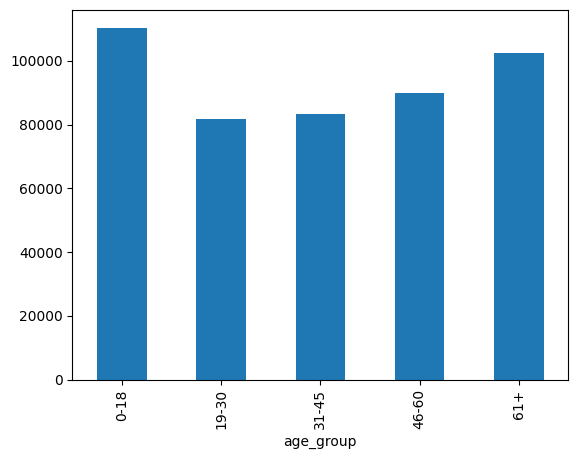

In [49]:
df_superstore_customers['age_group'] = pd.cut(
    df_superstore_customers['age'], 
    bins=[0,18,30,45,60,100], 
    labels=['0-18','19-30','31-45','46-60','61+']
)
df_superstore_customers.groupby('age_group')['annual_income'].mean().plot(kind='bar')

#Los menores de 18 tienen los ingresos mas altos y eso es raro. Se debe a la aleatoriedad de asignacion de clientes a las transacciones.

<Axes: xlabel='age', ylabel='annual_income'>

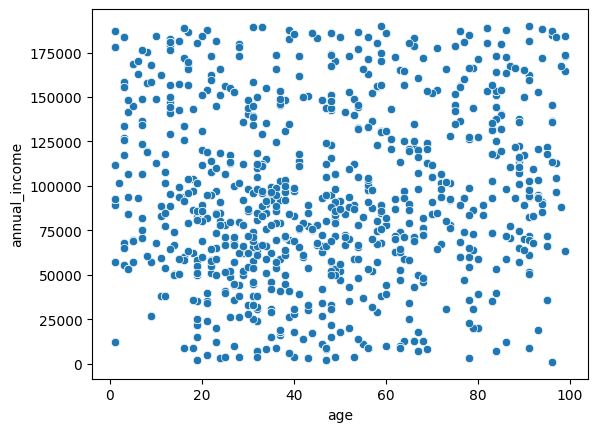

In [50]:
sns.scatterplot( x='age', y='annual_income',data=df_superstore_customers)

<Axes: xlabel='gender'>

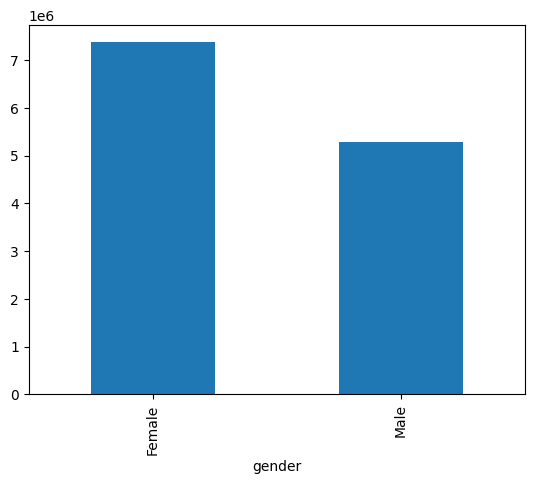

In [51]:
df_superstore_customers.groupby('gender')['sales'].sum().plot(kind='bar')

<Axes: xlabel='profession'>

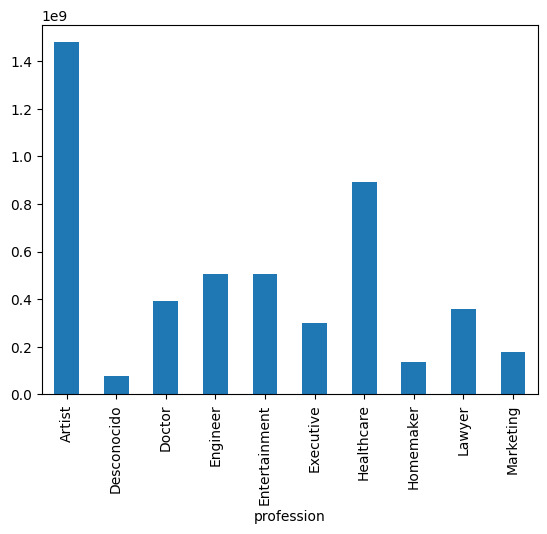

In [52]:
df_superstore_customers.groupby('profession')['annual_income'].sum().plot(kind='bar')

<Axes: xlabel='discount', ylabel='profit'>

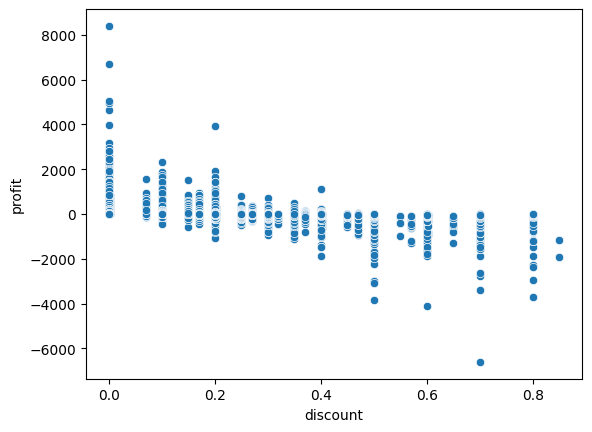

In [53]:
sns.scatterplot(x='discount', y='profit', data=df_superstore_customers)

<Axes: xlabel='quantity', ylabel='sales'>

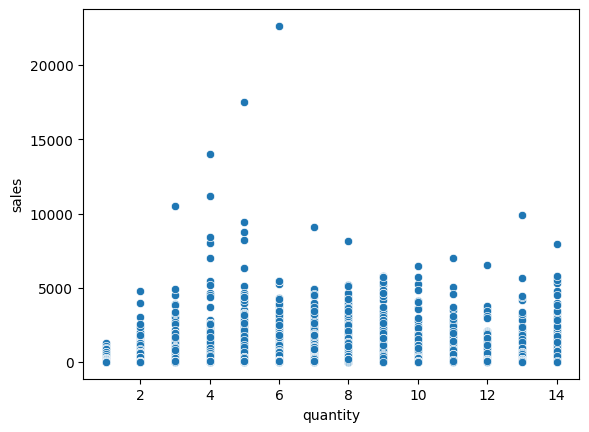

In [54]:
sns.scatterplot(x='quantity', y='sales', data=df_superstore_customers)

<Axes: xlabel='category'>

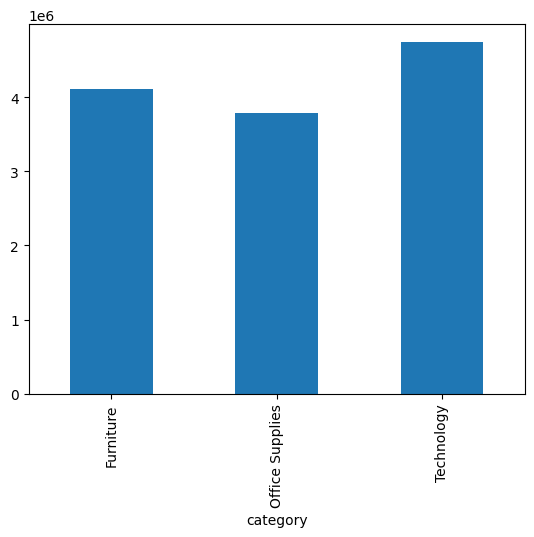

In [55]:
df_superstore_customers.groupby('category')['sales'].sum().plot(kind='bar')

<Axes: xlabel='sub_category'>

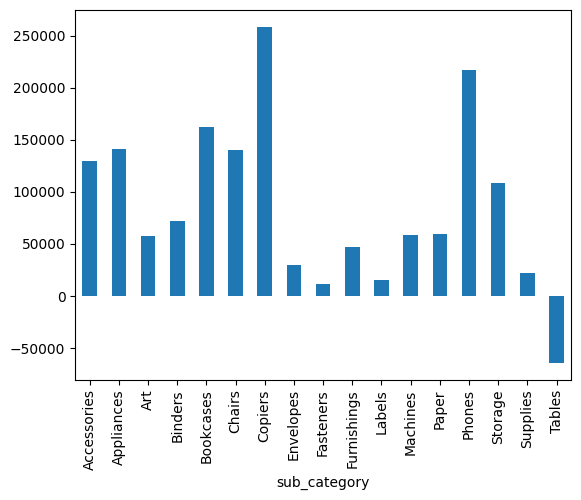

In [56]:
df_superstore_customers.groupby('sub_category')['profit'].sum().plot(kind='bar')

<Axes: xlabel='country'>

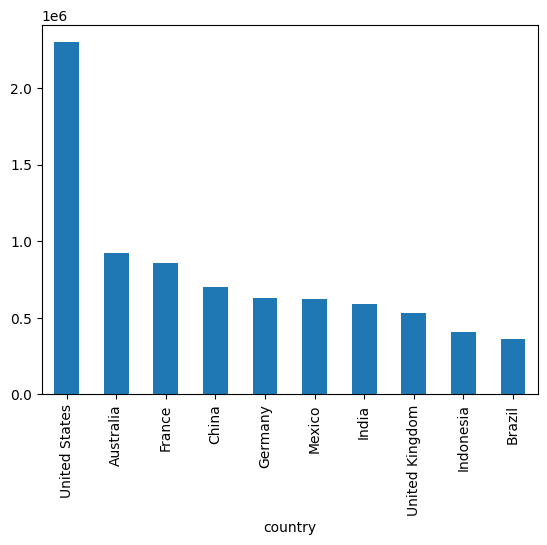

In [57]:
df_superstore_customers.groupby('country')['sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

<Axes: xlabel='order_date'>

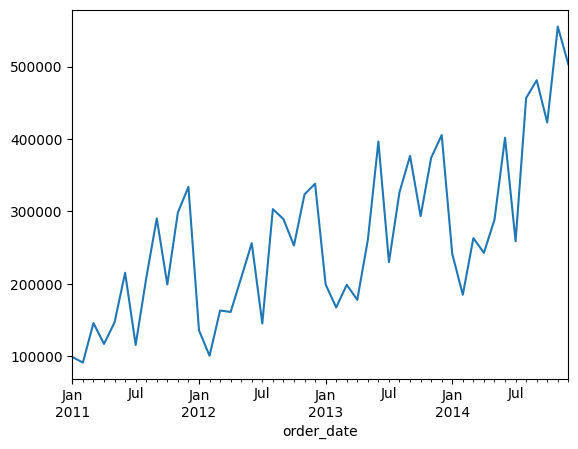

In [58]:
df_superstore_customers.groupby(df_superstore_customers['order_date'].dt.to_period('M'))['sales'].sum().plot(kind='line')

===========================================================

ANALISIS ESTADISTICO

=========================================================== 

<Axes: >

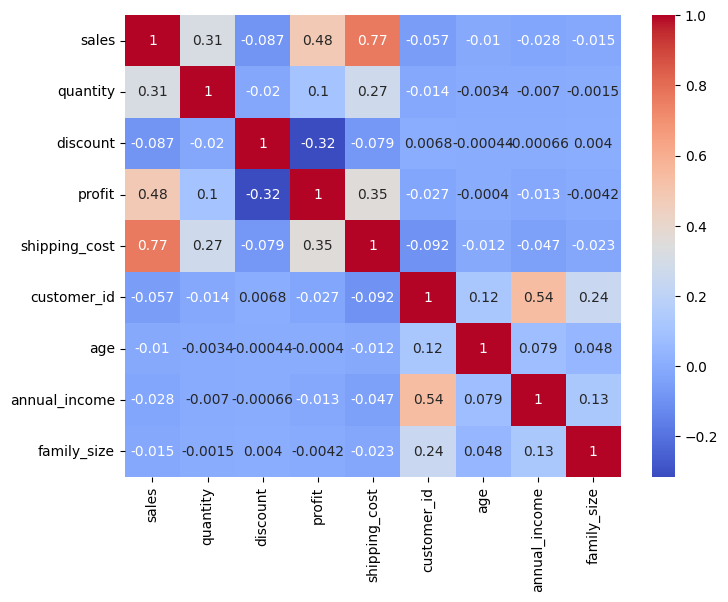

In [59]:
plt.figure(figsize=(8,6))
corr = df_superstore_customers.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')


<Axes: xlabel='sales', ylabel='Count'>

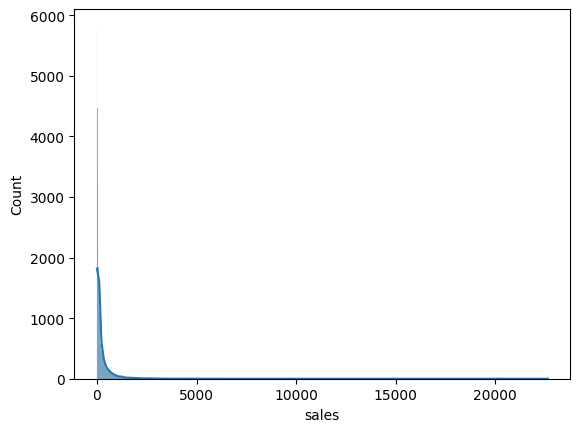

In [60]:
sns.histplot(df_superstore_customers['sales'], kde=True)

In [61]:
df_superstore_customers.groupby('gender')['sales'].mean()

gender
Female    246.408524
Male      246.605238
Name: sales, dtype: float64

In [62]:
df_superstore_customers.groupby('segment')['profit'].mean()

segment
Consumer       28.254008
Corporate      28.596042
Home Office    29.648847
Name: profit, dtype: float64

In [63]:
df_superstore_customers['sales'].std() / df_superstore_customers['sales'].mean()

np.float64(1.978028361813419)

In [64]:
df_superstore_customers.groupby(df_superstore_customers['order_date'].dt.to_period('Y'))['sales'].agg(['mean','std'])

,mean,std
order_date,,
2011,251.105901,536.893640
2012,244.247281,450.299914
2013,246.811106,494.719419
2014,245.272139,477.630355


<function matplotlib.pyplot.show(close=None, block=None)>

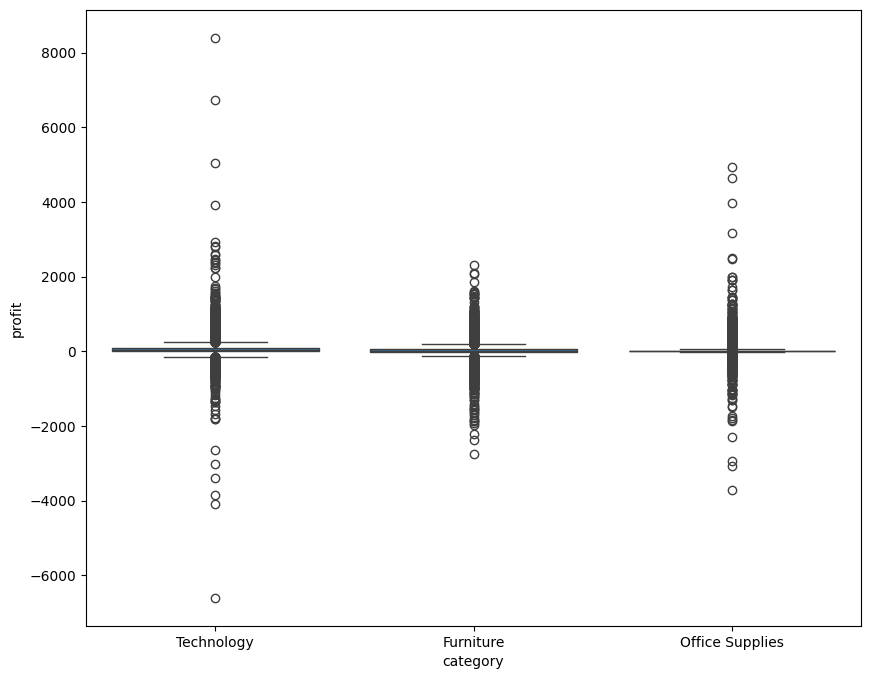

In [65]:
plt.figure(figsize=(10,8))
sns.boxplot(x='category', y='profit', data=df_superstore_customers)
plt.show

In [66]:
corr_qty_sales = df_superstore_customers[['quantity','sales']].corr().iloc[0,1]
print(f"Correlación entre quantity y sales: {corr_qty_sales:.2f}")


Correlación entre quantity y sales: 0.31


In [67]:
total_sales = df_superstore_customers.sum(numeric_only=True)
print(total_sales)

sales            1.264250e+07
quantity         1.783120e+05
discount         7.329728e+03
profit           1.467457e+06
shipping_cost    1.352821e+06
customer_id      1.992491e+07
age              2.399812e+06
annual_income    4.831463e+09
family_size      1.712980e+05
dtype: float64


# 📊 Análisis Exploratorio de Datos (EDA) y Análisis Estadístico

Tras unir los datasets de transacciones y clientes, nos centramos en variables clave relacionadas con tiempo, logística, cliente, producto, localización y métricas de negocio.

---

## 🔹 Análisis Exploratorio de Datos (EDA)

**Principales hallazgos:**
- **Clientes:** el 58,3% de las transacciones corresponden a clientes *Female* y el 41,7% a *Male*.  
- **Profesión:** destacan *Artist* (30,9%), *Healthcare* (17,5%), *Entertainment* (10,3%), *Engineer* (10%) y *Doctor* (8%).  
- **Segmento de cliente:** el segmento *Consumer* concentra el 51,7% de las transacciones.  
- **Categoría de producto:** predominan *Office Supplies*, seguidos de *Furniture* y *Technology*.  
- **País:** Estados Unidos lidera con el 19,4% de las ventas, seguido por Australia (5,5%).  

**Relaciones relevantes:**
- **Edad vs ingresos:** el grupo 0–18 aparece con ingresos muy altos, lo cual es inconsistente y refleja la naturaleza artificial del merge; por detrás, destacan los clientes mayores de 61 años.  
- **Descuentos y beneficios:** clara relación negativa → a mayor descuento, menor beneficio.  
- **Categorías y ventas:** *Technology* es la categoría más fuerte en ventas.  
- **Subcategorías y beneficios:** *Copiers* y *Phones* concentran más beneficio, mientras que *Tables* generan pérdidas.  
- **Ventas por país:** Estados Unidos lidera con diferencia.  
- **Evolución temporal:** entre enero de 2011 y julio de 2014 las ventas muestran altibajos, pero con tendencia creciente (de ~100.000 a más de 500.000).  

---

## 🔹 Análisis Estadístico

**Correlaciones (heatmap):**
- Ventas–Beneficio: **0.48** (relación positiva).  
- Descuento–Beneficio: **-0.32** (relación negativa).  
- Ventas–Coste de envío: **0.77** (relación positiva).  
- Ventas–Cantidad: **0.31** (positiva, pero débil).  

**Distribuciones:**
- Las ventas (`sales`) tienen una distribución **sesgada a la derecha**:  
  - La mayoría de transacciones se concentran en valores bajos (0–1.000).  
  - Pocas transacciones superan los 20.000 → son outliers de alto valor.  

**Comparaciones de medias:**
- Ticket medio por género: prácticamente idéntico (*Male ≈ Female*).  
- Beneficio medio por segmento: muy similar entre grupos, con *Home Office* ligeramente superior (~29,6).  

**Variabilidad:**
- El coeficiente de variación de `sales` es **1,97** → las ventas son muy dispersas e inestables respecto a su media.  

**Evolución temporal:**
- El ticket medio anual de ventas se mantiene estable (~245–251) entre 2011 y 2014.  
- Cada año presenta una desviación elevada, lo que refleja alta volatilidad.  

**Variabilidad por categoría (boxplot):**
- *Technology* presenta operaciones muy rentables pero también pérdidas fuertes.  
- *Furniture* es la más inestable, con muchos valores negativos.  
- *Office Supplies* es más estable, aunque también con outliers.  

---

## 🔹 Conclusión

Con este análisis (EDA + estadístico), se identifican patrones clave:  
- *Female* concentra más transacciones, pero el ticket medio no varía por género.  
- Profesiones creativas (*Artist*) y sanitarias (*Healthcare*) concentran ingresos más altos.  
- *Technology* lidera en ventas y beneficios, aunque con riesgo de pérdidas en algunos productos.  
- *Tables* es la única subcategoría claramente deficitaria.  
- Estados Unidos es, con diferencia, el mercado más importante.  
- Las políticas de descuento afectan negativamente a la rentabilidad.  
- Las ventas son volátiles y con alta dispersión, pero la tendencia temporal es creciente.  

---
